# CACAO: PREDICCIÓN Y ANÁLISIS DE PRECIOS AGROPECUARIOS

## RÚBRICA

La estructructura lógica del notebook reproduccible debe incluir:

*   carga
*   limpieza,
*   EDA
*   modelado y pronóstico,
* conclusiones
<br>
Estos pasos deben ejecutarse de inicio a fin sin errores y deben contener: instrucciones claras para instalación de librerías y ruta de datos.


### Carga de datos

El código de
carga es claro y
generalizable
(uso de rutas
relativas, lectura
robusta), se
documenta
origen de datos,
diccionario de
variables y
justificación de
selección.

### Procesos de limpieza

Deben estar bien
justificados
(tratamiento de
NA, outliers,
cambios de
frecuencia).

### EDA Series de tiempo

 El código debe ser legible, tener visualizaciones claras de la serie (tendencia, estacionalidad) con interpretación breve.

### Modelado y pronóstico

Se ajustan uno o
más modelos
apropiados para
series de tiempo
(p. ej.
ARIMA/ETS/Prop
het/LSTM), se
justifica su
elección, se
separan conjuntos de
entrenamiento/p
rueba y se
reportan
métricas (MAE,
RMSE, etc.) con
interpretación
crítica de
resultados.

### Conclusiones

Código
ordenado,
nombres de
variables
significativos,
comentarios
concisos que
explican pasos
clave,
conclusiones
finales que
conectan
resultados del
modelo con el
problema de
precios de
granos.

###

## MODELOS ESTOCÁTICOS

In [ ]:
pip install yfinance prophet pandas matplotlib openpyxl

Prediccion de Precios del Cacao - Mexico e Internacional

Descargando datos oficiales de futuros de cacao (CC=F)...
Columnas despues de limpiar: ['Close', 'High', 'Low', 'Open', 'Volume']
Datos internacionales cargados correctamente: 1258 dias
   Ultimo precio (USD/ton): 3909.00
   Fecha mas reciente: 2026-05-19

Entrenando modelo Prophet...

Ultimos 10 dias + Prediccion
             ds     yhat  yhat_lower  yhat_upper
1613 2027-05-10 -3307.98   -15153.12     7768.66
1614 2027-05-11 -3314.90   -14357.13     7364.16
1615 2027-05-12 -3322.52   -14555.29     7519.00
1616 2027-05-13 -3331.15   -14443.61     8037.38
1617 2027-05-14 -3341.05   -14652.56     7806.01
1618 2027-05-15 -3352.52   -14961.28     7566.82
1619 2027-05-16 -3365.78   -15009.18     7492.40
1620 2027-05-17 -3381.07   -14998.02     7662.61
1621 2027-05-18 -3398.57   -14893.30     7511.99
1622 2027-05-19 -3418.42   -14644.50     7854.45

Prediccion aproximada:
   Hoy:                  3909.00 USD/ton
   En 6 meses:        

<Figure size 1400x800 with 0 Axes>

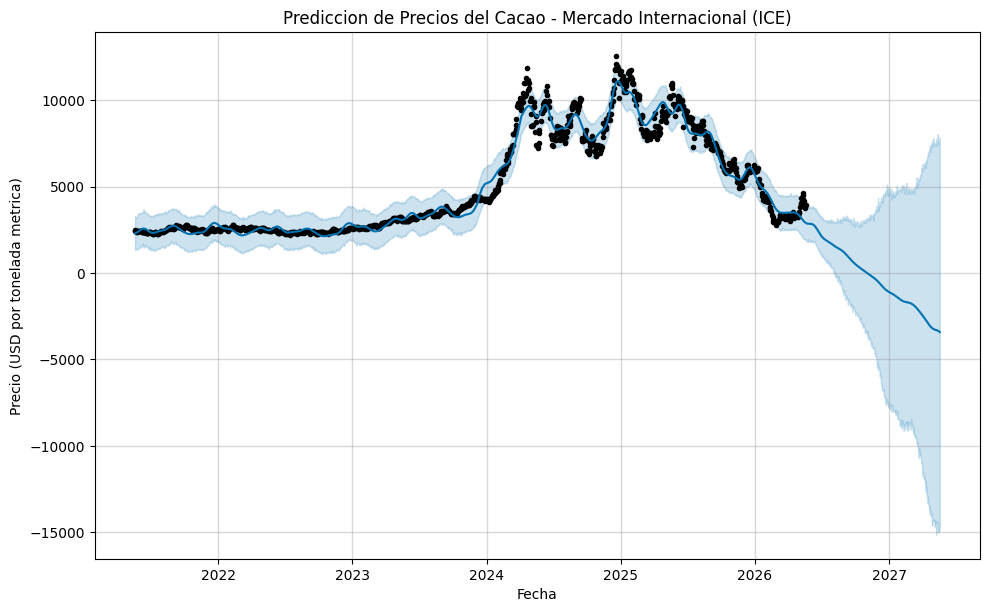


Archivo guardado: prediccion_cacao_internacional_20260520.csv

Codigo ejecutado.


In [ ]:
import yfinance as yf
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Prediccion de Precios del Cacao - Mexico e Internacional")
print("=" * 80)

# 1. Descarga de datos internacionales (ICE Nueva York)
print("\nDescargando datos oficiales de futuros de cacao (CC=F)...")

ticker = "CC=F"
data_int = yf.download(ticker, period="5y", interval="1d", progress=False, auto_adjust=True)

if data_int.empty:
    print("Error: No se pudieron descargar los datos. Verifica tu conexion a internet.")
else:
    # Solucion para xMultiInde (el problema actual)
    if isinstance(data_int.columns, pd.MultiIndex):
        data_int = data_int.droplevel(1, axis=1)   # Elimina el segundo nivel ('CC=F')

    print("Columnas despues de limpiar:", data_int.columns.tolist())

    # Seleccion segura de la columna de precio
    if 'Close' in data_int.columns:
        close_col = 'Close'
    elif 'Adj Close' in data_int.columns:
        close_col = 'Adj Close'
    else:
        print("Error: No se encontro columna de precio.")
        print("Columnas disponibles:", data_int.columns.tolist())
        close_col = None

    if close_col is not None:
        # Preparacion del DataFrame para Prophet
        df_int = data_int[[close_col]].reset_index()
        df_int = df_int.rename(columns={'Date': 'ds', close_col: 'y'})

        # Limpieza de datos
        df_int['y'] = pd.to_numeric(df_int['y'], errors='coerce')
        df_int = df_int.dropna(subset=['y', 'ds']).reset_index(drop=True)

        if len(df_int) < 30:
            print("Error: Muy pocos datos validos para entrenar el modelo.")
        else:
            print(f"Datos internacionales cargados correctamente: {len(df_int)} dias")
            print(f"   Ultimo precio (USD/ton): {df_int['y'].iloc[-1]:.2f}")
            print(f"   Fecha mas reciente: {df_int['ds'].iloc[-1].date()}")

            # 2. Modelo Prophet
            print("\nEntrenando modelo Prophet...")

            model = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=0.1,
                interval_width=0.95
            )

            model.fit(df_int)

            # Prediccion a 365 dias
            future = model.make_future_dataframe(periods=365)
            forecast = model.predict(future)

            # 3. Resultados
            print("\nUltimos 10 dias + Prediccion")
            print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10).round(2))

            # Predicciones clave
            last_date = forecast['ds'].iloc[-1]
            pred_6m = forecast[forecast['ds'] >= last_date - pd.Timedelta(days=183)].iloc[0]
            pred_12m = forecast.iloc[-1]

            print(f"\nPrediccion aproximada:")
            print(f"   Hoy:                  {df_int['y'].iloc[-1]:.2f} USD/ton")
            print(f"   En 6 meses:           {pred_6m['yhat']:.2f} USD/ton")
            print(f"   En 12 meses:          {pred_12m['yhat']:.2f} USD/ton")

            # 4. Grafico
            plt.figure(figsize=(14, 8))
            model.plot(forecast, xlabel='Fecha', ylabel='Precio (USD por tonelada metrica)')
            plt.title('Prediccion de Precios del Cacao - Mercado Internacional (ICE)')
            plt.grid(True, alpha=0.3)
            plt.show()

            # 5. Guardar resultados
            fecha_hoy = datetime.now().strftime("%Y%m%d")
            forecast.to_csv(f'prediccion_cacao_internacional_{fecha_hoy}.csv', index=False)

            print(f"\nArchivo guardado: prediccion_cacao_internacional_{fecha_hoy}.csv")


print("\nCodigo ejecutado.")

## INVESTIGACIÓN DE OPERACIONES

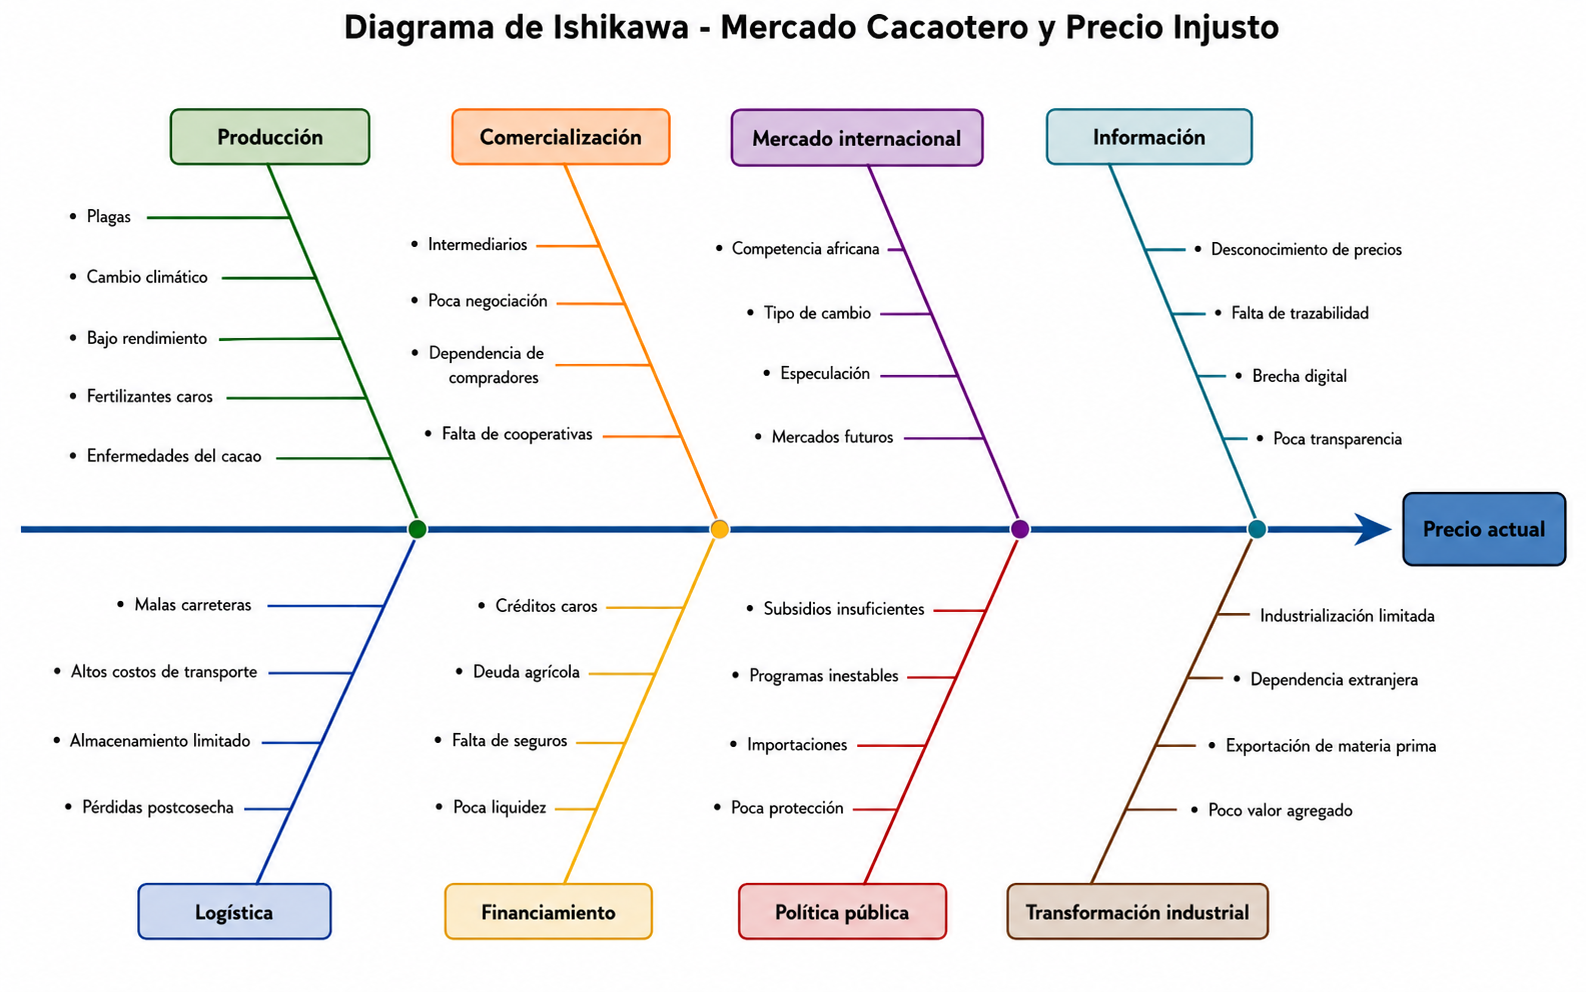

*Gráfico de elaboración propia.Diagrama Fishbone*

## APRENDIZAJE MÁQUINA

In [ ]:

import ipywidgets as widgets
from IPython.display import display, clear_output

# ====================== BASE DE DATOS ======================
marcas_mexicanas = {
    "kixocolatl": {"origen": "Yucatán", "tipo": "artesanal", "cacao": "alto", "descripcion": "Herencia maya, bean to bar"},
    "feliu": {"origen": "Jalisco", "tipo": "gourmet", "cacao": "alto", "descripcion": "Uno de los mejores de México"},
    "cuna de piedra": {"origen": "Chiapas", "tipo": "bean to bar", "cacao": "alto", "descripcion": "Cacao criollo mexicano"},
    "moctezuma": {"origen": "Michoacán", "tipo": "artesanal", "cacao": "alto", "descripcion": "Muy bien valorado"},
    "la rifa": {"origen": "CDMX", "tipo": "artesanal", "cacao": "medio-alto", "descripcion": "Calidad excepcional"},
    "wolter": {"origen": "México", "tipo": "tradicional", "cacao": "medio", "descripcion": "Clásico mexicano"},
    "picard": {"origen": "México", "tipo": "artesanal", "cacao": "medio-alto", "descripcion": "Buena variedad"},
    "ibarra": {"origen": "México", "tipo": "tableta", "cacao": "medio", "descripcion": "Ideal para chocolate caliente"},
    "sicao": {"origen": "México", "tipo": "profesional", "cacao": "alto", "descripcion": "Muy usado por chefs"},
}

todas_marcas = {**marcas_mexicanas, **{
    "lindt": {"origen": "Suiza", "fortaleza": "Suavidad y derretido"},
    "godiva": {"origen": "Bélgica", "fortaleza": "Lujo y bombones"},
    "valrhona": {"origen": "Francia", "fortaleza": "Gourmet profesional"},
    "hershey": {"origen": "EE.UU.", "fortaleza": "Dulce y accesible"},
    "cadbury": {"origen": "Reino Unido", "fortaleza": "Cremoso"},
    "ritter sport": {"origen": "Alemania", "fortaleza": "Variedades divertidas"},
    "abuelita": {"origen": "México (Nestlé)", "fortaleza": "Clásico para atole"},
}}



In [ ]:
#  BUSCADOR
def buscador_eficaz():
    clear_output(wait=True)
    print(" BUSCADOR DE CHOCOLATES MEXICANOS\n")

    busqueda = widgets.Text(
        placeholder='Busca por nombre, origen, tipo... (ej: chiapas, alto, gourmet)',
        description='Buscar:',
        layout=widgets.Layout(width='600px')
    )

    filtro_tipo = widgets.Dropdown(
        options=['Todos', 'Artesanal', 'Bean to bar', 'Gourmet', 'Tableta', 'Tradicional'],
        value='Todos',
        description='Tipo:',
        layout=widgets.Layout(width='400px')
    )

    filtro_cacao = widgets.Dropdown(
        options=['Todos', 'Alto', 'Medio-alto', 'Medio'],
        value='Todos',
        description='Cacao:',
        layout=widgets.Layout(width='400px')
    )

    filtro_origen = widgets.Dropdown(
        options=['Todos', 'Yucatán', 'Chiapas', 'Jalisco', 'Michoacán', 'CDMX', 'México'],
        value='Todos',
        description='Origen:',
        layout=widgets.Layout(width='400px')
    )

    output = widgets.Output()

    def realizar_busqueda(*args):
        with output:
            clear_output()
            texto = busqueda.value.lower().strip()
            resultados = []

            for marca, info in todas_marcas.items():
                coincide = True

                # Búsqueda por texto (en nombre, origen, tipo, descripción)
                if texto:
                    campos = [
                        marca.lower(),
                        info.get('origen', '').lower(),
                        info.get('tipo', '').lower(),
                        info.get('descripcion', '').lower(),
                        info.get('fortaleza', '').lower()
                    ]
                    if not any(texto in campo for campo in campos):
                        coincide = False

                # Filtros
                if filtro_tipo.value != 'Todos':
                    if filtro_tipo.value.lower() not in info.get('tipo', '').lower():
                        coincide = False

                if filtro_cacao.value != 'Todos':
                    if info.get('cacao') != filtro_cacao.value.lower():
                        coincide = False

                if filtro_origen.value != 'Todos':
                    if filtro_origen.value.lower() not in info.get('origen', '').lower():
                        coincide = False

                if coincide:
                    resultados.append((marca, info))

            if resultados:
                print(f"Se encontraron {len(resultados)} resultado(s):\n")
                for marca, info in resultados:
                    es_mexicana = marca in marcas_mexicanas
                    print(f"**{marca.upper()}** {'🇲🇽' if es_mexicana else 'internacional'}")
                    print(f"Origen: {info.get('origen')}")
                    if es_mexicana:
                        print(f"Tipo: {info.get('tipo')} | Cacao: {info.get('cacao')}")
                        print(f"Descripción: {info.get('descripcion')}")
                    else:
                        print(f"Fortaleza: {info.get('fortaleza')}")
                    print("-" * 70)
            else:
                print("No se encontraron resultados. Intenta otros términos.")

    # Actualización automática
    busqueda.observe(realizar_busqueda, names='value')
    filtro_tipo.observe(realizar_busqueda, names='value')
    filtro_cacao.observe(realizar_busqueda, names='value')
    filtro_origen.observe(realizar_busqueda, names='value')

    # Resultados iniciales
    realizar_busqueda()

    display(busqueda, filtro_tipo, filtro_cacao, filtro_origen, output)

In [ ]:
# INTERFAZ
print("BUSCADOR + RECOMENDADOR DE CHOCOLATES MEXICANOS")
print("=" * 75)

buscar_marca_input = widgets.Text(
    placeholder='Búsqueda rápida por nombre (ej: kixocolatl)',
    description='Marca exacta:',
    layout=widgets.Layout(width='500px')
)

btn_busqueda_rapida = widgets.Button(description="Buscar Marca Exacta", button_style='info')
btn_buscador_eficaz = widgets.Button(description="Abrir Buscador Avanzado", button_style='success')
btn_recomendador = widgets.Button(description="Recomendador", button_style='warning')

output_area = widgets.Output()

def busqueda_rapida(b):
    with output_area:
        clear_output()
        marca = buscar_marca_input.value.strip()
        if marca:
            # Llamar a la función de búsqueda simple
            marca_lower = marca.lower()
            if marca_lower in todas_marcas:
                info = todas_marcas[marca_lower]
                es_mex = marca_lower in marcas_mexicanas
                print(f"**{marca.upper()}** {'→ MARCA MEXICANA' if es_mex else '→ Internacional'}")
                print(f"Origen: {info.get('origen')}")
                if es_mex:
                    print(f"Tipo: {info.get('tipo')} | Cacao: {info.get('cacao')}")
                    print(f"Descripción: {info.get('descripcion')}")
                else:
                    print(f"Fortaleza: {info.get('fortaleza')}")
            else:
                print(f"Marca '{marca}' no encontrada.")
        else:
            print("Escribe una marca.")

def abrir_buscador_eficaz(b):
    with output_area:
        buscador_eficaz()

def abrir_recomendador(b):
    with output_area:

        print("Recomendador en desarrollo... Por ahora usa el Buscador Avanzado.")

btn_busqueda_rapida.on_click(busqueda_rapida)
btn_buscador_eficaz.on_click(abrir_buscador_eficaz)
btn_recomendador.on_click(abrir_recomendador)

display(buscar_marca_input, btn_busqueda_rapida, btn_buscador_eficaz, btn_recomendador, output_area)

BUSCADOR + RECOMENDADOR DE CHOCOLATES MEXICANOS


Text(value='', description='Marca exacta:', layout=Layout(width='500px'), placeholder='Búsqueda rápida por nom…

Button(button_style='info', description='Buscar Marca Exacta', style=ButtonStyle())

Button(button_style='success', description='Abrir Buscador Avanzado', style=ButtonStyle())

Button(button_style='warning', description='Recomendador', style=ButtonStyle())

Output()

## ALMACENAMIENTO DE GRANDES VÓLUMENES DE DATOS

Para alimentar nuestro buscador de chocolates emplearemos los siguientes datasets.


*   **Flavors of cacao.-** Extraída de Kaggle,centrada en chocolate amargo, incluye origen de los granos y es internacional.
*   **OpenFoodfacts.-** Extrajimos una lista de alimentos vendidos que contienen chocolate, incluye info. nutricional.
*   **Scrapping de supermercados .-** Aplicación de la minería de datos, nos permitirá incluir precios y disponibilidad.
<br>
Las fuentes originales pueden encontrarse aquí: https://drive.google.com/drive/folders/1WN1iw7jTgo9uaGDPpKYMS18_2_W37Ne7?usp=sharing



## MINERÍA DE DATOS

In [ ]:
# Detector de Stay Points + detección de tienda cercana

import math

# 5 tiendas
tiendas = [
    {
        "nombre": "Cuauhtémoc 180, Del Carmen, Coyoacán",
        "lat": 19.3496,
        "lon": -99.1617
    },
    {
        "nombre": "Av. México Coyoacán 375, Xoco",
        "lat": 19.3614,
        "lon": -99.1674
    },
    {
        "nombre": "Av. Insurgentes Sur 1362, Actipan",
        "lat": 19.3726,
        "lon": -99.1781
    },
    {
        "nombre": "Julio Verne 104B, Polanco",
        "lat": 19.4304,
        "lon": -99.1942
    },
    {
        "nombre": "Ermita Iztapalapa 3417, Xalpa",
        "lat": 19.3387,
        "lon": -99.0185
    }
]

RADIO_CERCANIA = 0.02


def calcular_distancia(lat1, lon1, lat2, lon2):
    return math.sqrt((lat2 - lat1) ** 2 + (lon2 - lon1) ** 2)


def tienda_mas_cercana(lat, lon):
    menor_distancia = None
    tienda_cercana = None

    for tienda in tiendas:
        distancia = calcular_distancia(lat, lon, tienda["lat"], tienda["lon"])

        if menor_distancia is None or distancia < menor_distancia:
            menor_distancia = distancia
            tienda_cercana = tienda

    return tienda_cercana, menor_distancia


def analizar_estancia(coordenadas, tiempo_minimo_min):
    print(f"{'HORA':<10} | {'COORDENADA':<25} | {'ESTADO'}")
    print("-" * 80)

    for i in range(len(coordenadas) - 1):
        p1 = coordenadas[i]
        p2 = coordenadas[i + 1]

        duracion = p2["tiempo"] - p1["tiempo"]

        if duracion >= tiempo_minimo_min:
            estado = "STAY POINT (Lugar de interés)"
        else:
            estado = "TRÁNSITO (Movimiento)"

        tienda, distancia = tienda_mas_cercana(p1["lat"], p1["lon"])

        aviso = ""
        if distancia <= RADIO_CERCANIA:
            aviso = f" --> CERCA DE: {tienda['nombre']}"

        print(
            f"{p1['hora']:<10} | ({p1['lat']}, {p1['lon']}){'':<6} | {estado}{aviso}"
        )


# Simulación de rastro GPS
ruta_gps = [
    {'hora': '07:00', 'lat': 19.3495, 'lon': -99.1618, 'tiempo': 0},
    {'hora': '07:15', 'lat': 19.3610, 'lon': -99.1670, 'tiempo': 15},
    {'hora': '08:00', 'lat': 19.3724, 'lon': -99.1780, 'tiempo': 60},
    {'hora': '14:00', 'lat': 19.4302, 'lon': -99.1940, 'tiempo': 420}
]

analizar_estancia(ruta_gps, 30)

HORA       | COORDENADA                | ESTADO
--------------------------------------------------------------------------------
07:00      | (19.3495, -99.1618)       | TRÁNSITO (Movimiento) --> CERCA DE: Cuauhtémoc 180, Del Carmen, Coyoacán
07:15      | (19.361, -99.167)       | STAY POINT (Lugar de interés) --> CERCA DE: Av. México Coyoacán 375, Xoco
08:00      | (19.3724, -99.178)       | STAY POINT (Lugar de interés) --> CERCA DE: Av. Insurgentes Sur 1362, Actipan
